In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip install torchinfo

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import PIL
import time
import glob
from IPython import display
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device = 'cuda:0'
torch.__version__

'2.8.0+cu126'

## ACGAN

### Dataset 준비

In [4]:
import torchvision.transforms as v2
from torchvision.datasets import FashionMNIST, MNIST

class Normalize(object):
    def __call__(self, sample):
        sample = np.array(sample)
        image = (sample - 127.5) / 127.5
        return torch.FloatTensor(image).unsqueeze(dim=0)

class Onehot(object):
    def __call__(self, sample):
        sample = sample
        target = np.eye(10)[sample]
        return torch.FloatTensor(target)

# Normalize data to [-1 ~ 1]
mnist_transform = v2.Compose([Normalize(),])
target_transform = v2.Compose([Onehot(),])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True,
                      download=True, target_transform=target_transform)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                     download=True, target_transform=target_transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.78MB/s]


tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


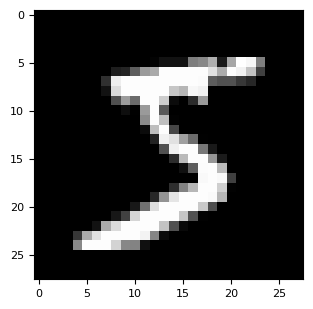

In [5]:
plt.imshow(train_dataset[0][0][0, :, :], cmap='gray')
print(train_dataset[0][1])

- model params

In [6]:
BUFFER_SIZE = 60000
BATCH_SIZE = 600
EPOCHS = 200
label_dim=10    # class_num.
noise_dim = 90  # latent vector dim.
IN_PUT_DIM=label_dim+noise_dim  # 100
num_examples_to_generate = 16
IMG_SHAPE=(28,28,1)

In [7]:
train_dataloader = DataLoader(train_dataset, BATCH_SIZE, True,num_workers=4)
test_dataloader = DataLoader(test_dataset, BATCH_SIZE, False,num_workers=4)

### Model define

In [8]:
# Generator model : CGAN과 동일
class ACGenerator(nn.Module):
    def __init__(self, input_dim):
        super(ACGenerator, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(input_dim, 256 * 7 * 7, bias=False),
            nn.Unflatten(1, (256, 7, 7)),
            nn.BatchNorm2d(256,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 5, 1,
                          padding=2, bias=False),
            nn.BatchNorm2d(128,momentum=0.8), #(128,7,7)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 5, 2,
                         padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(64,momentum=0.8),  #(64,14,14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 1, 5, 2,
                         padding=2, output_padding=1, bias=True),
            nn.Tanh() )         #(1,28,28)
    def forward(self, z, c):
        c = c.to(device)
        inputs = torch.cat([z, c], dim=1)
        out = self.generator(inputs)
        return out

acgenerator = ACGenerator(IN_PUT_DIM).to(device)
summary(acgenerator, input_size=[(BATCH_SIZE, noise_dim), (BATCH_SIZE, label_dim)])

Layer (type:depth-idx)                   Output Shape              Param #
ACGenerator                              [600, 1, 28, 28]          --
├─Sequential: 1-1                        [600, 1, 28, 28]          --
│    └─Linear: 2-1                       [600, 12544]              1,254,400
│    └─Unflatten: 2-2                    [600, 256, 7, 7]          --
│    └─BatchNorm2d: 2-3                  [600, 256, 7, 7]          512
│    └─LeakyReLU: 2-4                    [600, 256, 7, 7]          --
│    └─ConvTranspose2d: 2-5              [600, 128, 7, 7]          819,200
│    └─BatchNorm2d: 2-6                  [600, 128, 7, 7]          256
│    └─LeakyReLU: 2-7                    [600, 128, 7, 7]          --
│    └─ConvTranspose2d: 2-8              [600, 64, 14, 14]         204,800
│    └─BatchNorm2d: 2-9                  [600, 64, 14, 14]         128
│    └─LeakyReLU: 2-10                   [600, 64, 14, 14]         --
│    └─ConvTranspose2d: 2-11             [600, 1, 28, 28]        

In [9]:
# ACDiscriminator model
class ACDiscriminator(nn.Module):
    def __init__(self, label_dim):
        super(ACDiscriminator, self).__init__()
        self.discriminator = nn.Sequential(
            nn.Conv2d(1, 64, 5, 2, padding=2),
            nn.LeakyReLU(0.2), nn.Dropout(0.25),
            nn.Conv2d(64, 128, 5, 2, padding=2),
            nn.LeakyReLU(0.2), nn.Dropout(0.25),
            nn.Flatten() )
        self.discLinear = nn.Sequential(
            nn.Linear(128*7*7, 1),
            nn.Sigmoid() )
        self.acLinear = nn.Sequential(
            nn.Linear(128*7*7, 128),
            nn.Linear(128, label_dim) )
    def forward(self, x):
        out = self.discriminator(x)
        disc_out = self.discLinear(out)
        label_out = self.acLinear(out)
        return disc_out, label_out

acdiscriminator = ACDiscriminator(label_dim).to(device)
summary(acdiscriminator, input_size=[(BATCH_SIZE, 1, 28, 28)])

Layer (type:depth-idx)                   Output Shape              Param #
ACDiscriminator                          [600, 1]                  --
├─Sequential: 1-1                        [600, 6272]               --
│    └─Conv2d: 2-1                       [600, 64, 14, 14]         1,664
│    └─LeakyReLU: 2-2                    [600, 64, 14, 14]         --
│    └─Dropout: 2-3                      [600, 64, 14, 14]         --
│    └─Conv2d: 2-4                       [600, 128, 7, 7]          204,928
│    └─LeakyReLU: 2-5                    [600, 128, 7, 7]          --
│    └─Dropout: 2-6                      [600, 128, 7, 7]          --
│    └─Flatten: 2-7                      [600, 6272]               --
├─Sequential: 1-2                        [600, 1]                  --
│    └─Linear: 2-8                       [600, 1]                  6,273
│    └─Sigmoid: 2-9                      [600, 1]                  --
├─Sequential: 1-3                        [600, 10]                 --
│   

### Model 생성 및 학습조건 설정

In [10]:
lr = 2e-4
bce_loss = nn.BCELoss()
cce_loss = nn.CrossEntropyLoss()

acgenerator = acgenerator.to(device)
acdiscriminator = acdiscriminator.to(device)
optimizer_discriminator = torch.optim.Adam(acdiscriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(acgenerator.parameters(), lr=lr)

In [11]:
def generate_and_save_images(model, epoch):
    r, c = 10, 10
    fig, axs = plt.subplots(r, c)
    for i in range(c):
        noise_input = torch.FloatTensor(np.random.uniform(-1.0, 1.0, size=[10, noise_dim])).to(device)
        noise_label =  torch.FloatTensor(np.eye(BATCH_SIZE, 10)[np.full(fill_value=i, shape=(r, ))]).to(device)
        gen_imgs = model(noise_input, noise_label)
        gen_imgs = 0.5 * gen_imgs + 0.5
        for j in range(r):
            axs[j,i].imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap='gray')
            axs[j,i].axis('off')
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

### Training

Epoch:0 Loss D:0.3398662805557251 Loss G:3.8546080589294434


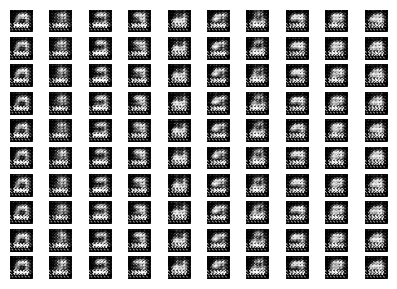

Epoch:10 Loss D:0.5409327745437622 Loss G:1.6988885402679443


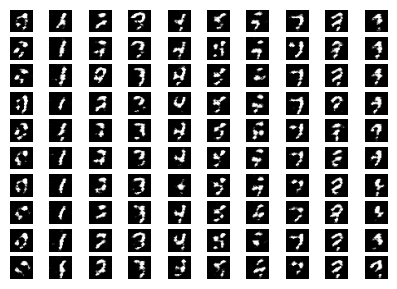

Epoch:20 Loss D:0.6013285517692566 Loss G:1.4512453079223633


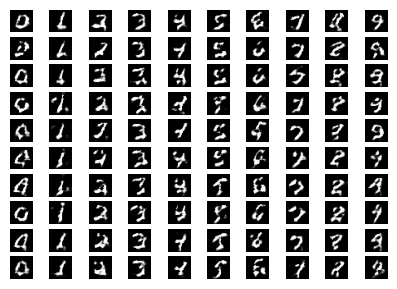

Epoch:30 Loss D:0.4631357789039612 Loss G:2.0147032737731934


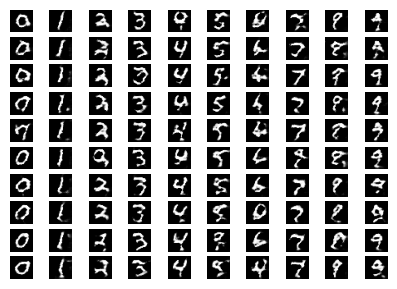

Epoch:40 Loss D:0.5196467041969299 Loss G:1.7038686275482178


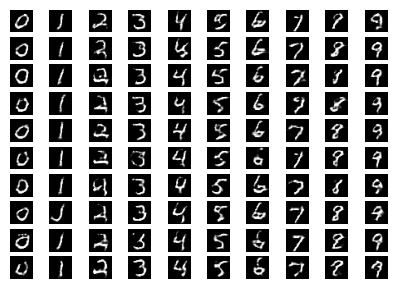

Epoch:50 Loss D:0.6527842283248901 Loss G:1.4158176183700562


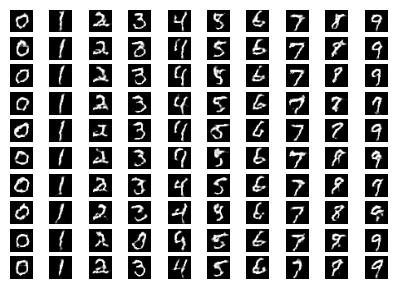

Epoch:60 Loss D:0.5487177968025208 Loss G:1.4734219312667847


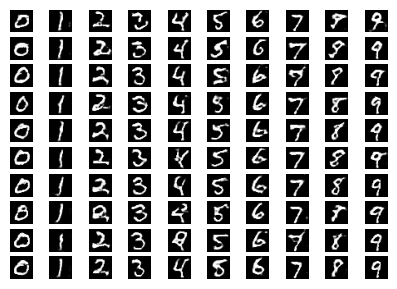

Epoch:70 Loss D:0.7140001654624939 Loss G:1.049575686454773


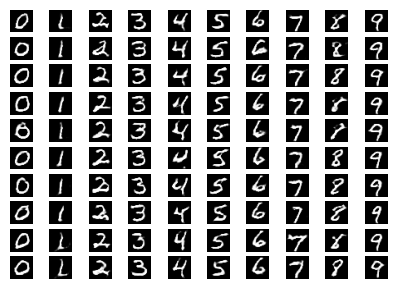

Epoch:80 Loss D:0.6518351435661316 Loss G:1.1642913818359375


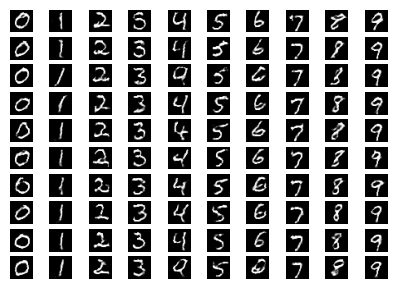

Epoch:90 Loss D:0.6004239320755005 Loss G:1.1237295866012573


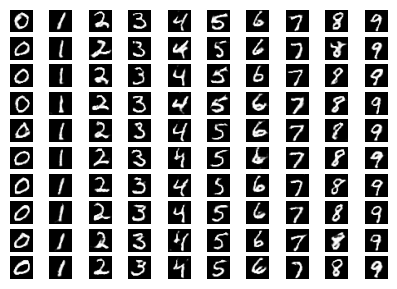

CPU times: user 2min 52s, sys: 15.7 s, total: 3min 8s
Wall time: 4min 8s


In [12]:
%%time
BATCH_SIZE = 600
EPOCHS = 100
for epoch in range(EPOCHS):
    for real_imgs, real_label in train_dataloader:
        real_imgs = real_imgs.to(device)
        real_labels = real_label.to(device)
        # Generate fake imgae, lable
        noise = torch.randn((BATCH_SIZE, noise_dim)).to(device)
        fake_labels = np.random.randint(0, 10, BATCH_SIZE)
        fake_labels = torch.FloatTensor(np.eye(BATCH_SIZE, 10)[fake_labels]).to(device)
        fake_imgs = acgenerator(noise, fake_labels)
        yb_real = torch.Tensor(BATCH_SIZE,1).fill_(1.0).to(device) # real_label
        yb_fake = torch.Tensor(BATCH_SIZE,1).fill_(0.0).to(device) # fake_label
        # Discriminator Training
        acdiscriminator.zero_grad()
        out_dis, out_label = acdiscriminator(real_imgs)
        loss_real = bce_loss(out_dis, yb_real)+ cce_loss(out_label, real_labels)
        out_dis, out_label = acdiscriminator(fake_imgs.detach())
        loss_fake = bce_loss(out_dis, yb_fake)+ cce_loss(out_label, fake_labels)
        loss_dis = (loss_real + loss_fake) / 2
        loss_dis.backward()
        optimizer_discriminator.step()
        # Generate fake image, label
        noise = torch.randn((BATCH_SIZE, noise_dim)).to(device)
        fake_labels = np.random.randint(0, 10, BATCH_SIZE)
        fake_labels = torch.FloatTensor(np.eye(BATCH_SIZE, 10)[fake_labels]).to(device)
        fake_imgs = acgenerator(noise, fake_labels)
        # Generator Training
        acgenerator.zero_grad()
        out_dis, out_label = acdiscriminator(fake_imgs)
        loss_gen = bce_loss(out_dis, yb_real)+ cce_loss(out_label, fake_labels)
        loss_gen.backward()
        optimizer_generator.step()
    if epoch % 10 == 0:  #10 #학습된 gen.의 성능 확인
        print(f"Epoch:{epoch} Loss D:{loss_dis} Loss G:{loss_gen}")
        generate_and_save_images(acgenerator, epoch)

# Wall time: 16min 16s

Epoch:0 Loss D:1.0825281143188477 Loss G:0.8356237411499023  
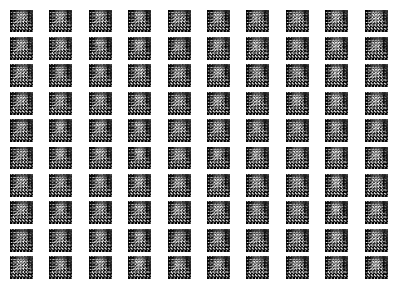

Epoch:10 Loss D:0.42821523547172546 Loss G:2.4257869720458984  
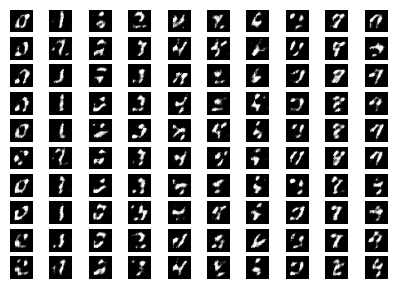

Epoch: 20 Loss D.: 0.4264296889305115, Loss G.: 2.145381212234497  
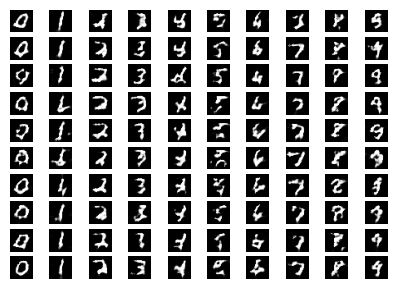

Epoch: 40 Loss D.: 0.4891084134578705, Loss G.: 1.7090198993682861  
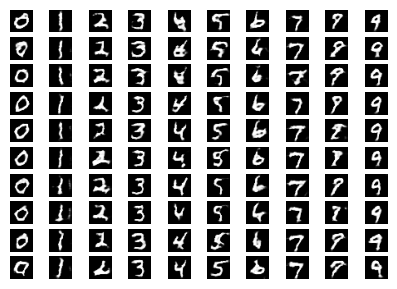

Epoch: 60 Loss D.: 0.44949787855148315, Loss G.: 1.4638139009475708  
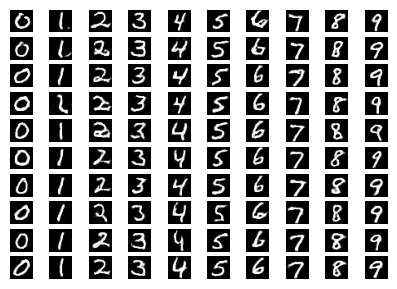

Epoch: 80 Loss D.: 0.8048756122589111, Loss G.: 0.8970762491226196  
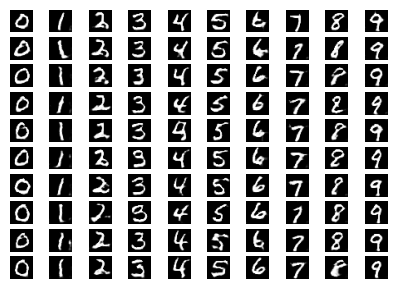

Epoch:90 Loss D:0.5415458679199219 Loss G:1.2374109029769897  
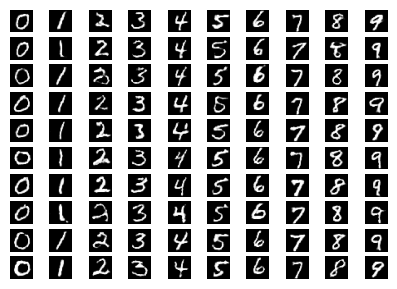

* Generator save

In [ ]:
# (Google Drive 연결 셀 제거 — 저장 경로는 /content/models/PT/ 로 바꿨다)
# # gdriver mount to load saved model
save_path='/content/models/PT/'

#torch.save(acgenerator, save_path+'acgan_generator.pt')


- model load

In [ ]:
generator = torch.load(save_path+'acgan_generator.pt')

In [ ]:
r, c = 10, 10
fig = plt.figure(figsize=(5,5))
plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
for i in range(c):
    noise_input = torch.randn((r, noise_dim))
    noise_label = np.eye(r, 10)[np.full(fill_value=i, shape=(r))]
    gen_imgs = acgenerator(torch.Tensor(noise_input).to(device), torch.Tensor(noise_label).to(device))###
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(r):
        ax = fig.add_subplot(r, c, j * r + i + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()

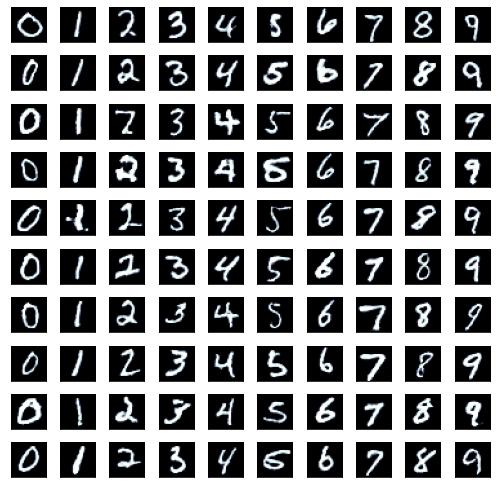